In [40]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import EDA as eda 
import Feature_eng as feature_eng
importlib.reload(eda)
importlib.reload(feature_eng)



<module 'Feature_eng' from 'c:\\Users\\Alexander  Hassfjell\\Documents\\Usyd\\Machine learning in buisness analytics\\ML project\\QBUS3820-Group-Assignment\\Feature_eng.py'>

In [14]:
import warnings
warnings.filterwarnings('ignore') 

# Plot settings
sns.set_context('notebook') # optimises figures for notebook display
sns.set_style('ticks') # set default plot style
colours = ['#4E79A7','#F28E2C','#E15759','#76B7B2','#59A14F', 
          '#EDC949','#AF7AA1','#FF9DA7','#9C755F','#BAB0AB']
sns.set_palette(colours) # set custom color scheme


%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['figure.dpi'] = 80
%config InlineBackend.figure_format = 'retina'

In [15]:
transactions, demographics, products, campaigns, campaign_descriptions, promotions = eda.retrieve_data()

### Define Churn variable

In [41]:
churn, churn_train, churn_valid, churn_test = feature_eng.churn(transactions, threshold_days=21)
print(churn.head())
print(churn.value_counts())
print(80*'=')
print(churn_train.value_counts())
print(churn_valid.value_counts())
print(churn_test.value_counts())

household_id
1    0
2    1
3    0
4    1
5    1
Name: churn, dtype: int64
churn
0    1897
1     572
Name: count, dtype: int64
churn
0    1332
1     396
Name: count, dtype: int64
churn
0    289
1     81
Name: count, dtype: int64
churn
0    276
1     95
Name: count, dtype: int64


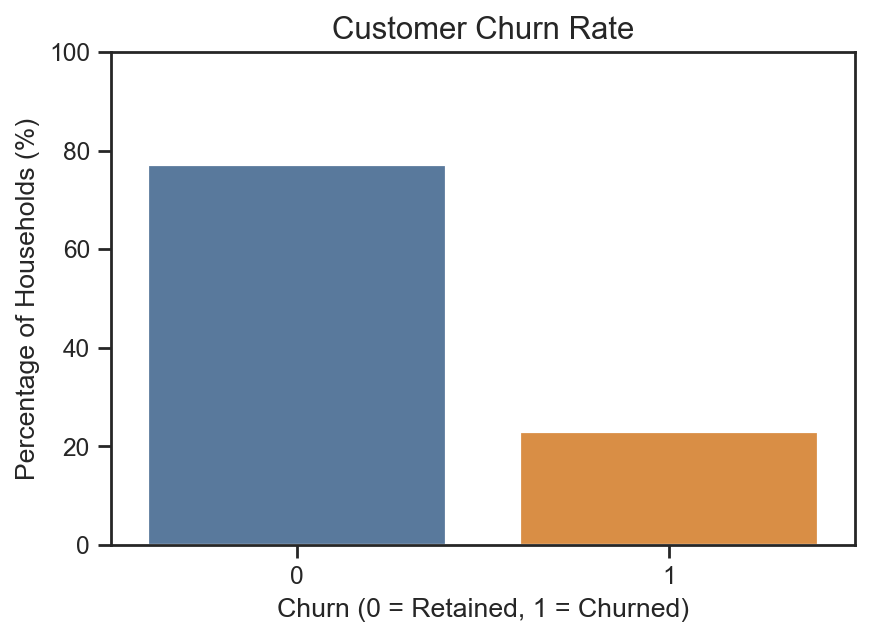

In [17]:
eda.plot_churn_rate(churn_train, colours)

## Demographics

### Demographics Data Cleaning

In [18]:
demographics_train, demographics_valid, demographics_test = eda.clean_demographics(eda.demographics)
ordinal_categorical_demographics = ['age', 'income', 'household_size', 'kids_count']
nominal_categorical_demographics = ['household_comp']
categorical_demographics = ordinal_categorical_demographics + nominal_categorical_demographics

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   household_id    801 non-null    int64 
 1   age             801 non-null    object
 2   income          801 non-null    object
 3   home_ownership  568 non-null    object
 4   marital_status  664 non-null    object
 5   household_size  801 non-null    object
 6   household_comp  801 non-null    object
 7   kids_count      801 non-null    object
dtypes: int64(1), object(7)
memory usage: 50.2+ KB
household_id        0
age                 0
income              0
home_ownership    233
marital_status    137
household_size      0
household_comp      0
kids_count          0
dtype: int64
Number of duplicate rows: 0

AGE - Unique Values:
['65+' '45-54' '35-44' '25-34' '55-64' '19-24']

INCOME - Unique Values:
['35-49K' '50-74K' '25-34K' '15-24K' 'Under 15K' '75-99K' '100-124K'
 '125-149K' '150-174K' '

Considering the amount of missing values in home_ownership and marital status, and the fact that they most likely don't have much informative data on customer churn, we remove these columns from the dataset. 

In [19]:
print(demographics_train.head())
print(demographics_valid.head())
print(demographics_test.head())
print(80*"=")
print(f"Training datapoints: {demographics_train.shape[0]}")
print(f"Validation datapoints: {demographics_valid.shape[0]}")
print(f"Test datapoints: {demographics_test.shape[0]}")

                age     income household_size    household_comp kids_count
household_id                                                              
1               65+     35-49K              2  2 Adults No Kids          0
1001          45-54     50-74K              1   1 Adult No Kids          0
1003          35-44     25-34K              1   1 Adult No Kids          0
1004          25-34     15-24K              1   1 Adult No Kids          0
101           45-54  Under 15K              4     2 Adults Kids          2
                age     income household_size    household_comp kids_count
household_id                                                              
1024          25-34  Under 15K              4     2 Adults Kids          2
1070          35-44     50-74K              2  2 Adults No Kids          0
113           35-44   125-149K              4     2 Adults Kids          2
1135          45-54     50-74K              2      1 Adult Kids          1
1137            65+     3

### Demographics Visualisation

(<Figure size 960x480 with 5 Axes>,
 array([[<Axes: title={'center': 'age'}>,
         <Axes: title={'center': 'income'}>,
         <Axes: title={'center': 'household_size'}>],
        [<Axes: title={'center': 'kids_count'}>,
         <Axes: title={'center': 'household_comp'}>, <Axes: >]],
       dtype=object))

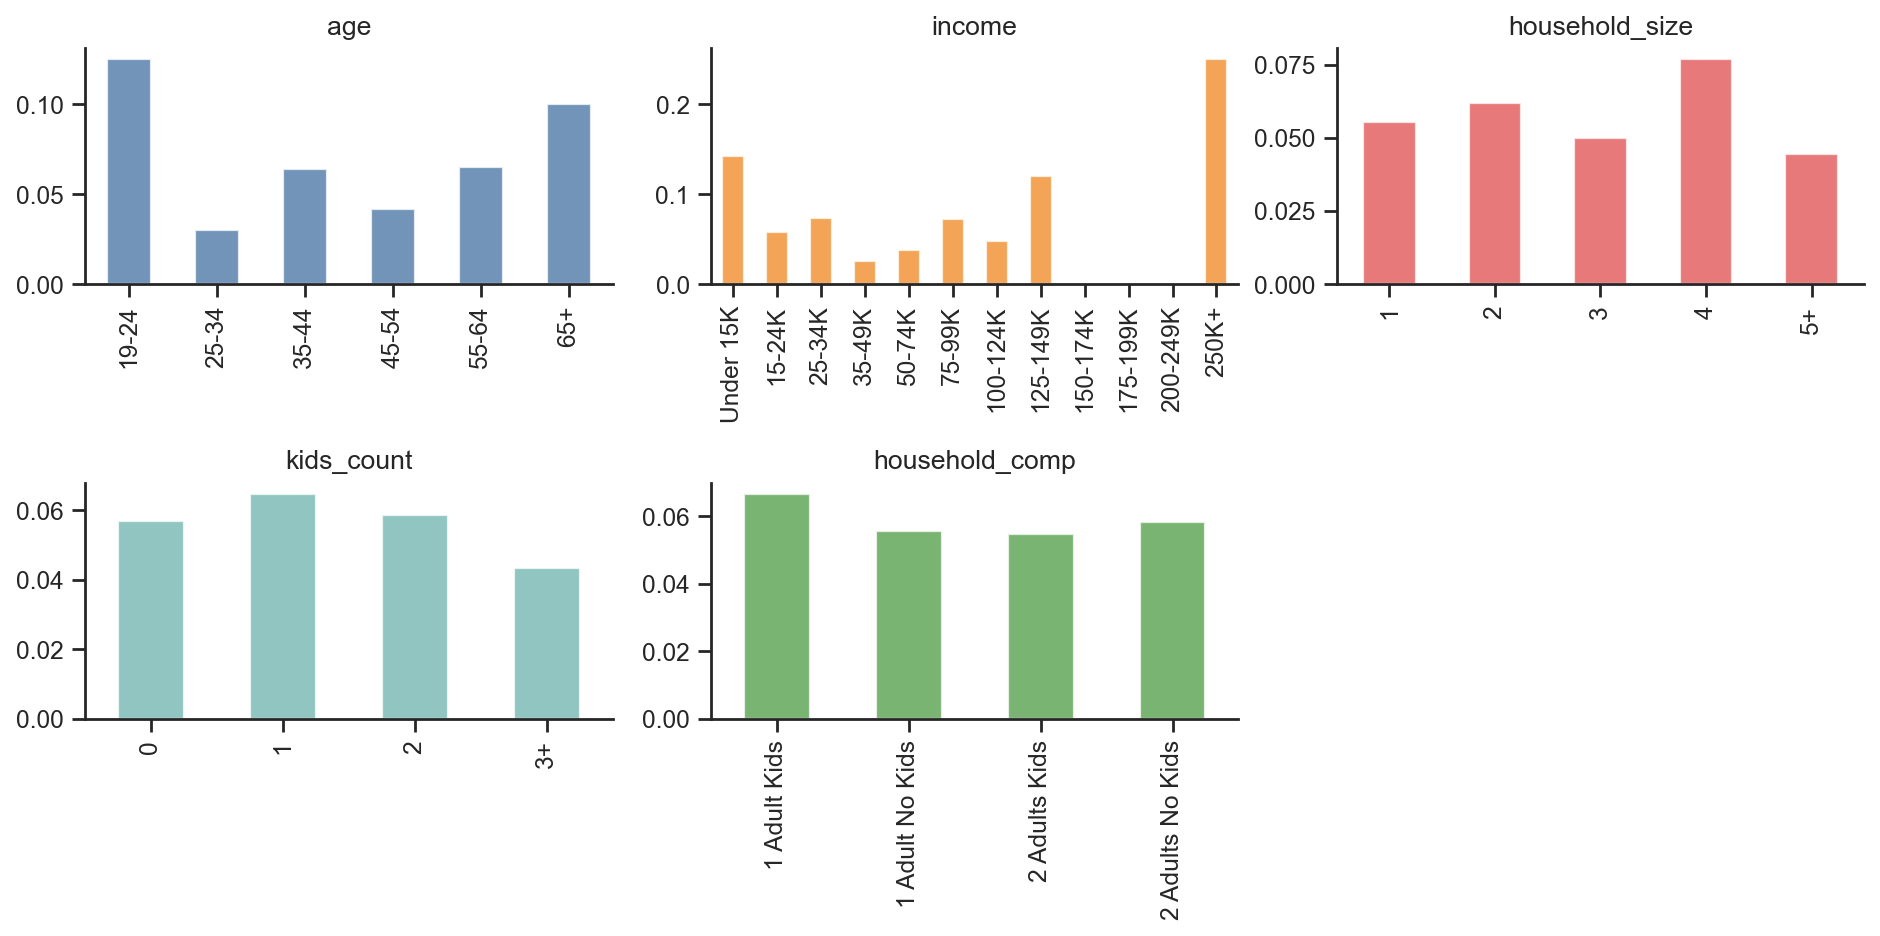

In [20]:
# Run Cleaned Demographics EDA function for variables to be defined
income_order = ['Under 15K', '15-24K', '25-34K', '35-49K', '50-74K', 
                '75-99K', '100-124K', '125-149K', '150-174K', '175-199K', 
                '200-249K', '250K+']
churn_demographics_train = churn_train.loc[demographics_train.index]
eda.crosstabplots(demographics_train[categorical_demographics], churn_demographics_train, {'income': income_order})

(<Figure size 1200x640 with 5 Axes>,
 array([<Axes: title={'center': 'age'}, ylabel='N households'>,
        <Axes: title={'center': 'income'}, ylabel='N households'>,
        <Axes: title={'center': 'household_size'}, ylabel='N households'>,
        <Axes: title={'center': 'kids_count'}, ylabel='N households'>,
        <Axes: title={'center': 'household_comp'}, ylabel='N households'>,
        <Axes: >], dtype=object))

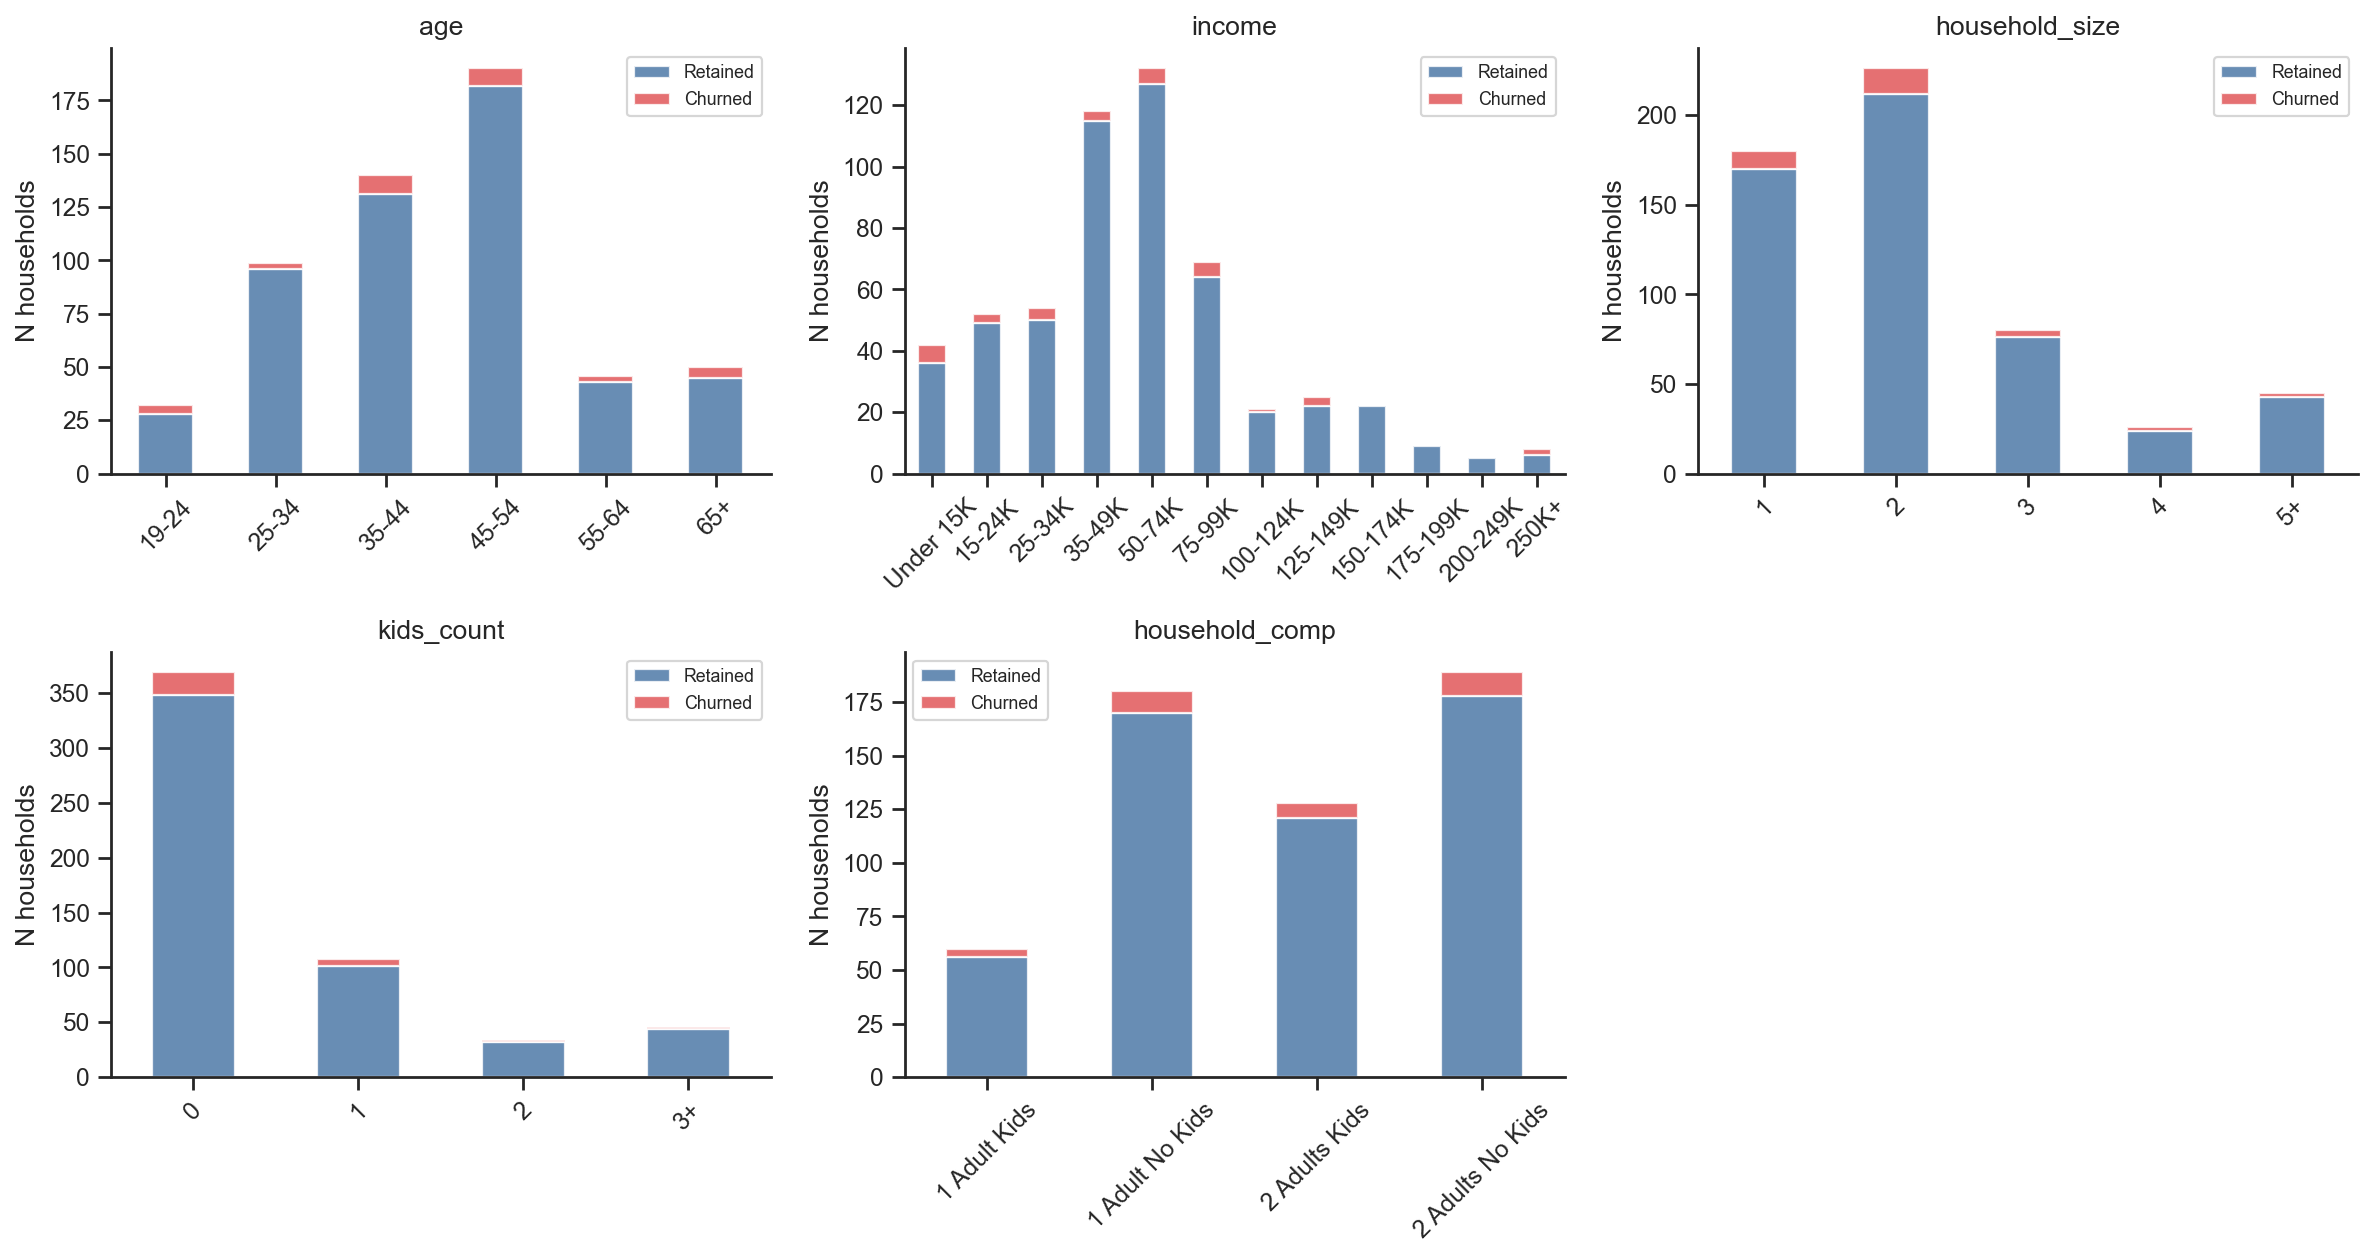

In [21]:
eda.churn_stack_plot(demographics_train[categorical_demographics], churn_demographics_train, column_orders={'income': income_order})

In [22]:
demographics_train['income'], demographics_valid['income'], demographics_test['income'] = feature_eng.collapse_income_categories(demographics_train, demographics_valid, demographics_test)
print(demographics_train['income'].value_counts())

income
50-74K       132
35-49K       118
100K+         90
75-99K        69
25-34K        54
15-24K        52
Under 15K     42
Name: count, dtype: int64


(<Figure size 960x480 with 5 Axes>,
 array([[<Axes: title={'center': 'age'}>,
         <Axes: title={'center': 'income'}>,
         <Axes: title={'center': 'household_size'}>],
        [<Axes: title={'center': 'kids_count'}>,
         <Axes: title={'center': 'household_comp'}>, <Axes: >]],
       dtype=object))

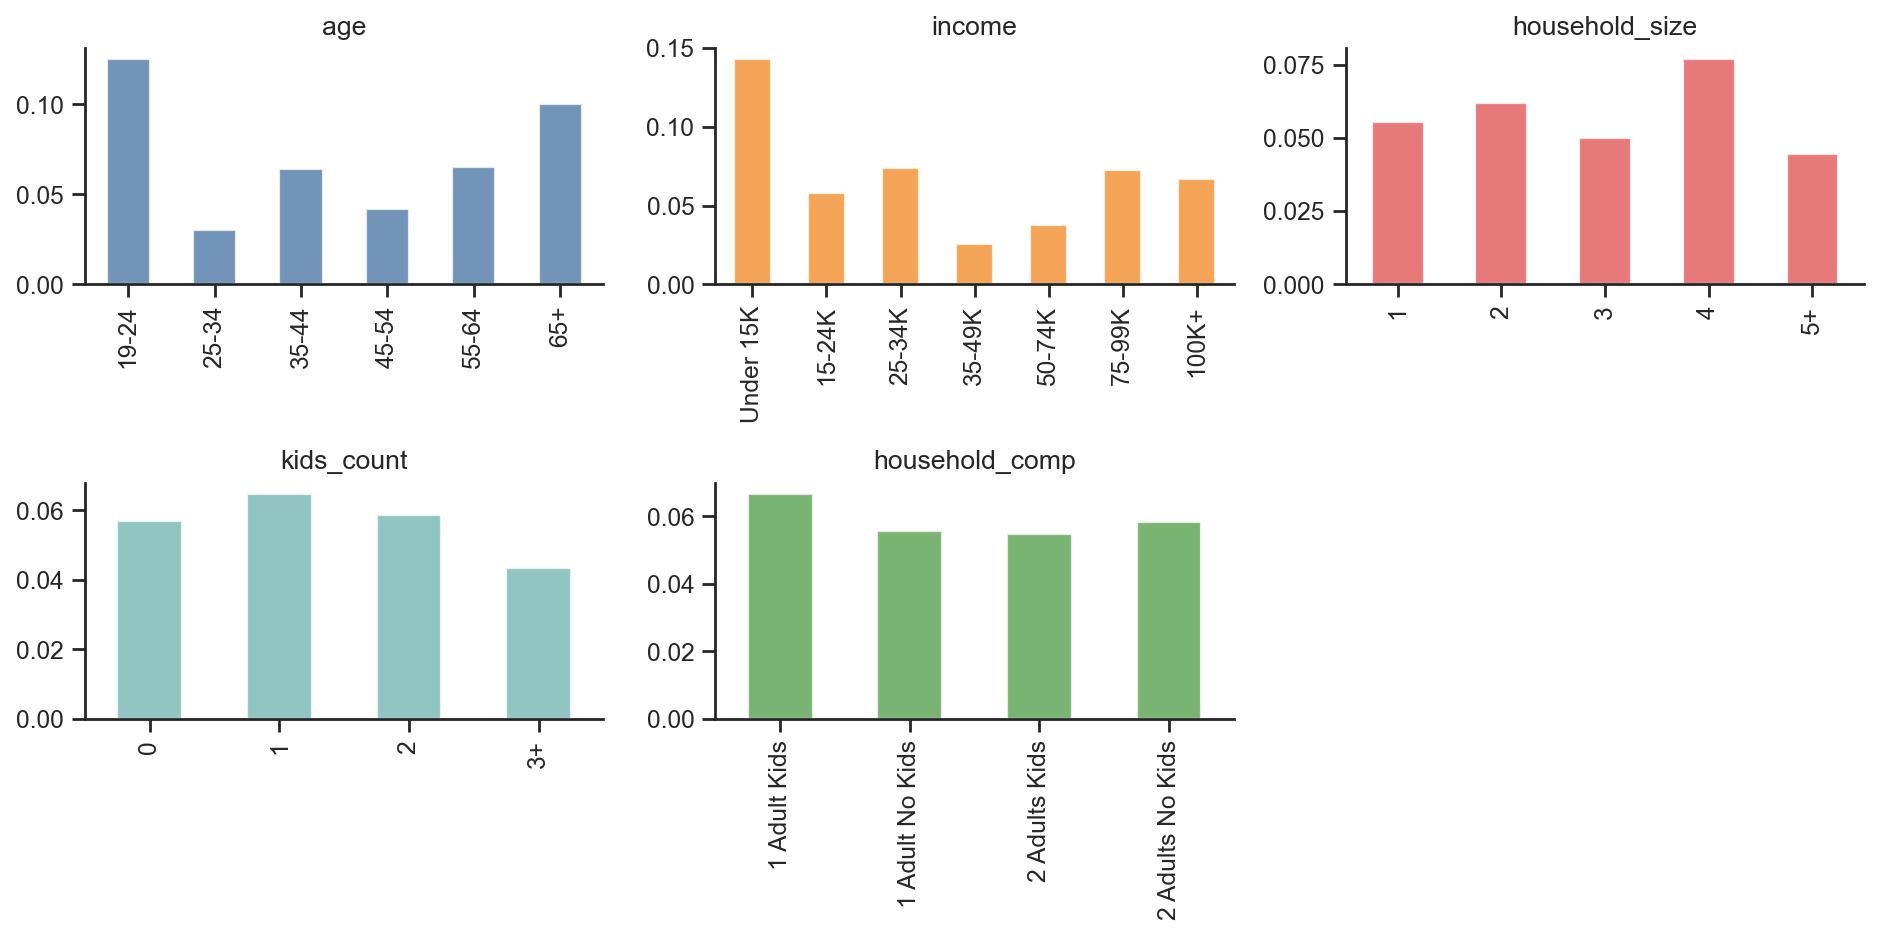

In [23]:
income_order = ['Under 15K', '15-24K', '25-34K', '35-49K', '50-74K', 
                '75-99K', '100K+']
eda.crosstabplots(demographics_train[categorical_demographics], churn_demographics_train, {'income': income_order})

(<Figure size 1200x640 with 5 Axes>,
 array([<Axes: title={'center': 'age'}, ylabel='N households'>,
        <Axes: title={'center': 'income'}, ylabel='N households'>,
        <Axes: title={'center': 'household_size'}, ylabel='N households'>,
        <Axes: title={'center': 'kids_count'}, ylabel='N households'>,
        <Axes: title={'center': 'household_comp'}, ylabel='N households'>,
        <Axes: >], dtype=object))

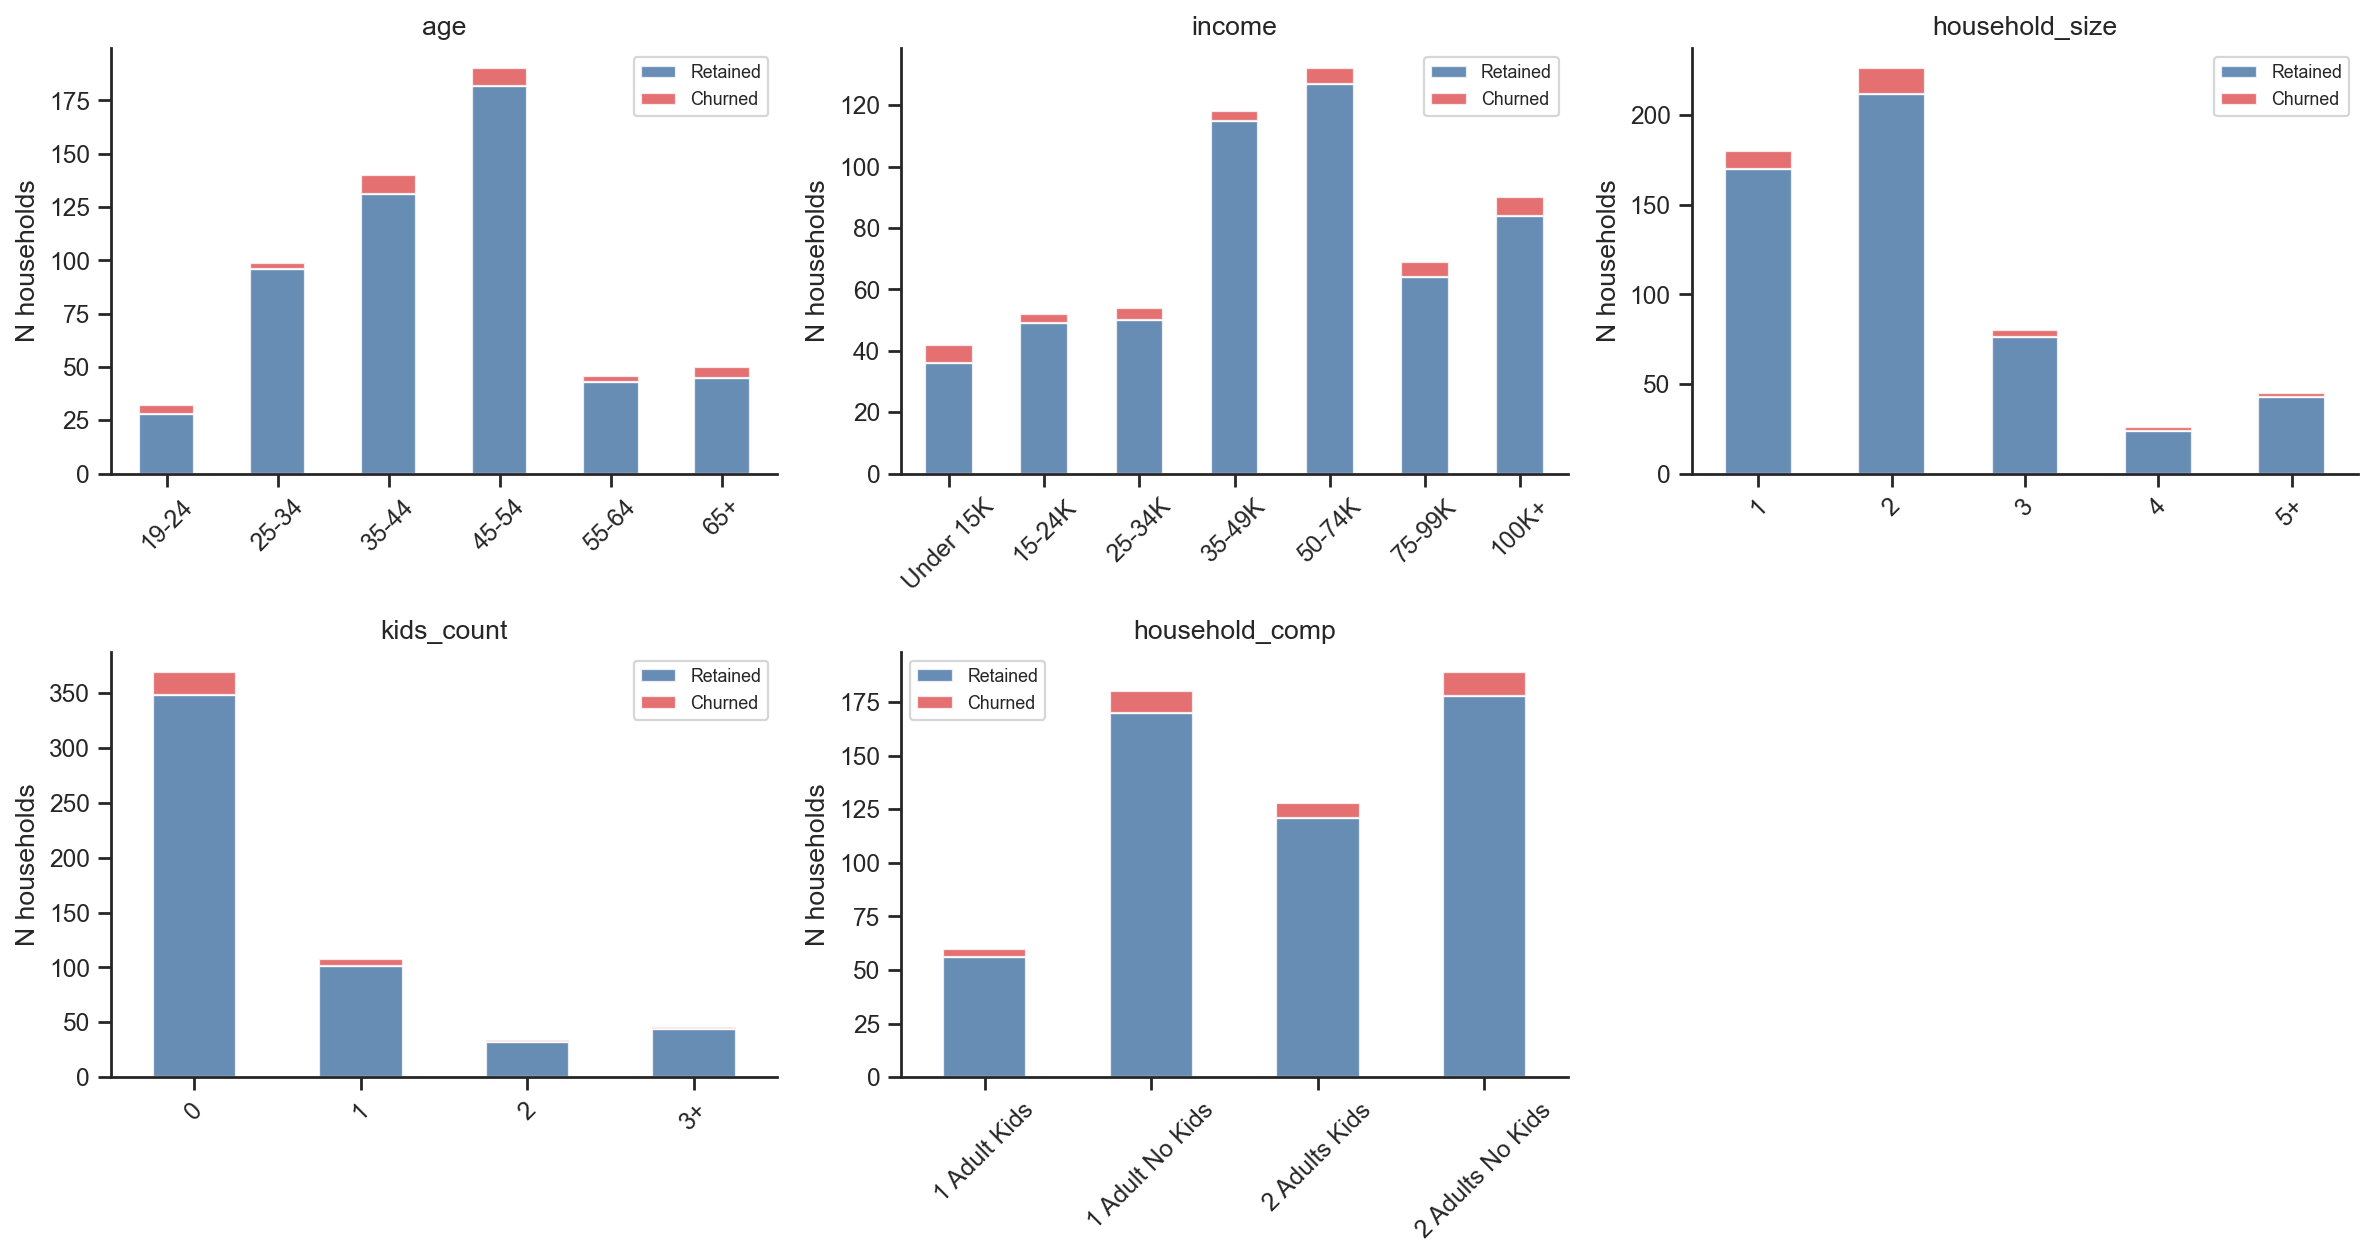

In [24]:
eda.churn_stack_plot(demographics_train[categorical_demographics], churn_demographics_train, column_orders={'income': income_order})

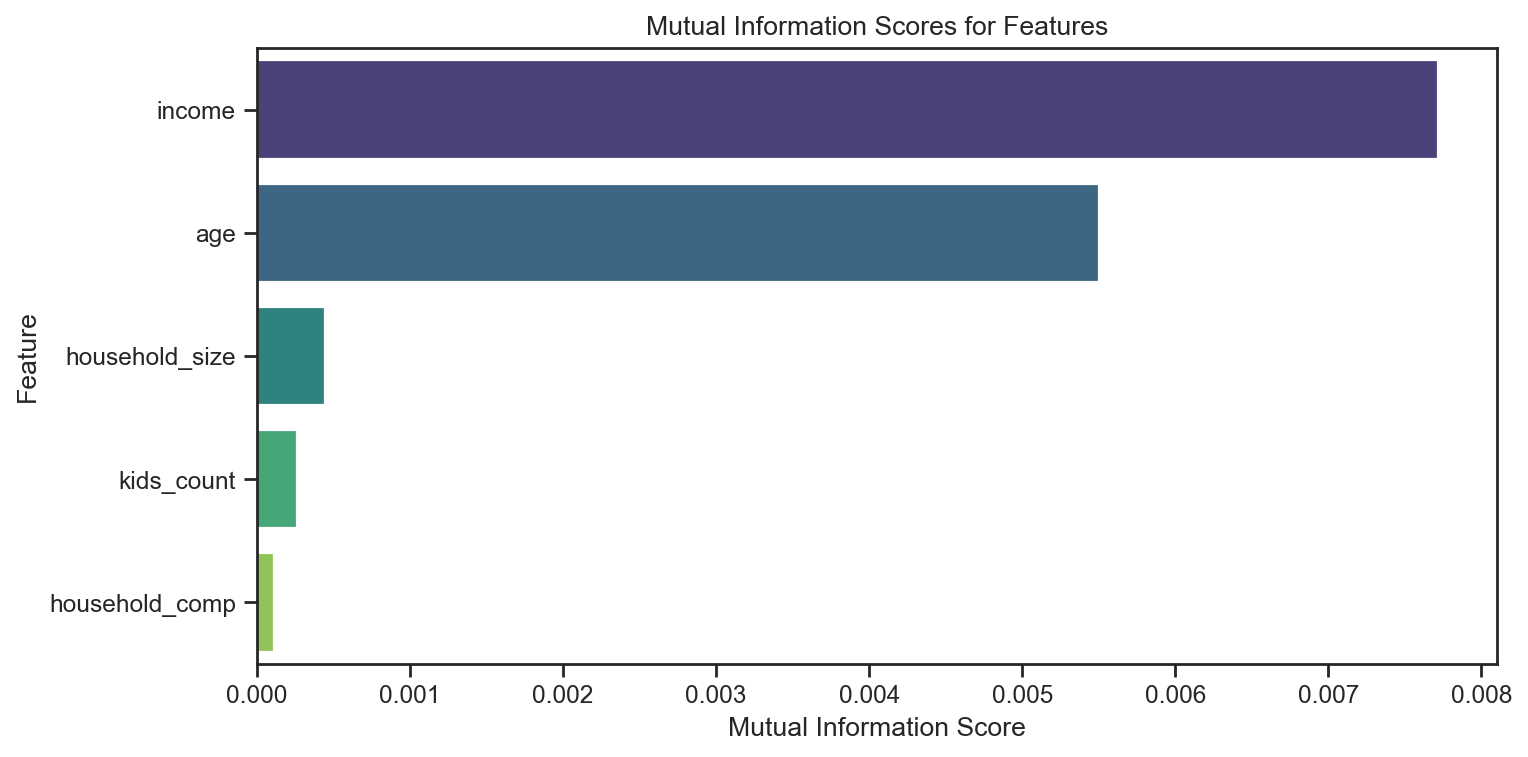

,MI
income,0.007716
age,0.005499
household_size,0.000446
kids_count,0.000258
household_comp,0.000110


In [25]:
eda.mutual_information_table(demographics_train, categorical=categorical_demographics, target=churn_demographics_train)

## Transactions

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1469307 entries, 0 to 1469306
Data columns (total 11 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   household_id           1469307 non-null  int64         
 1   store_id               1469307 non-null  int64         
 2   basket_id              1469307 non-null  int64         
 3   product_id             1469307 non-null  int64         
 4   quantity               1469307 non-null  int64         
 5   sales_value            1469307 non-null  float64       
 6   retail_disc            1469307 non-null  float64       
 7   coupon_disc            1469307 non-null  float64       
 8   coupon_match_disc      1469307 non-null  float64       
 9   week                   1469307 non-null  int64         
 10  transaction_timestamp  1469307 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(6)
memory usage: 123.3 MB
Missing values in trans

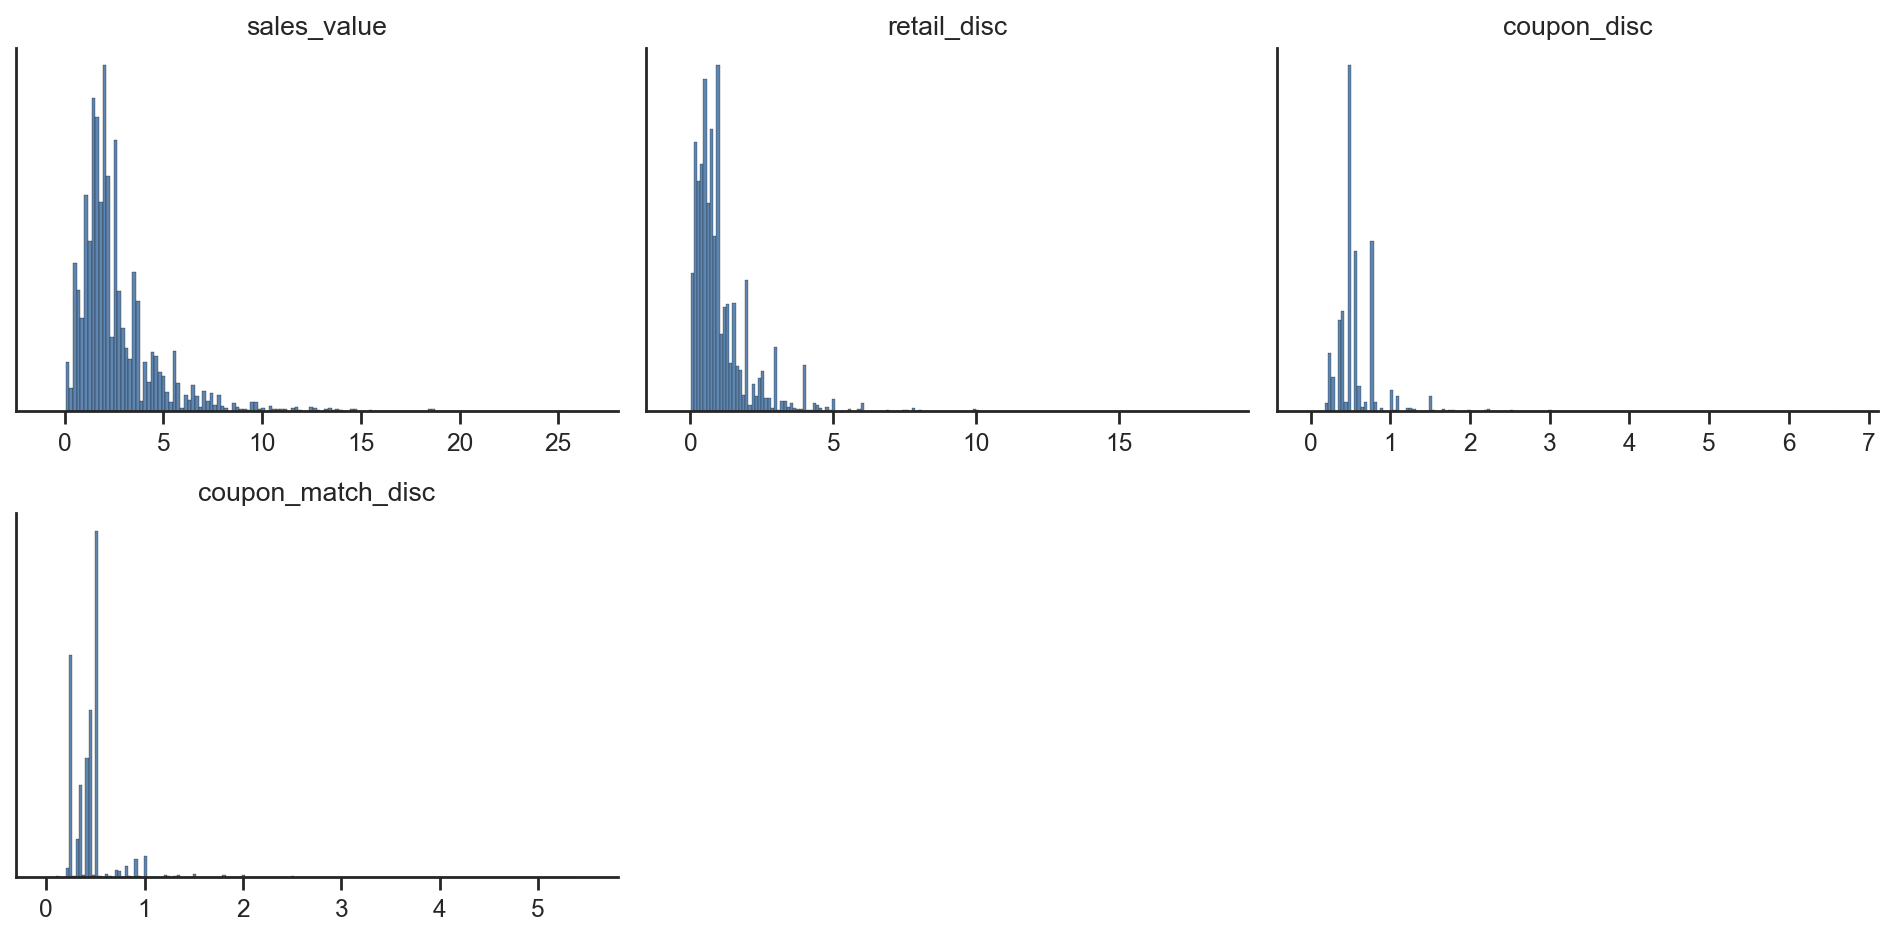

In [26]:
transactions_train, transactions_valid, transactions_test = eda.clean_transactions(eda.transactions)
print(eda.plot_transactions(eda.transactions))


(<Figure size 960x240 with 3 Axes>,
 array([<Axes: title={'center': 'Total Spend'}>,
        <Axes: title={'center': 'Transaction Frequency'}>,
        <Axes: title={'center': 'Avg Basket Size'}>], dtype=object))

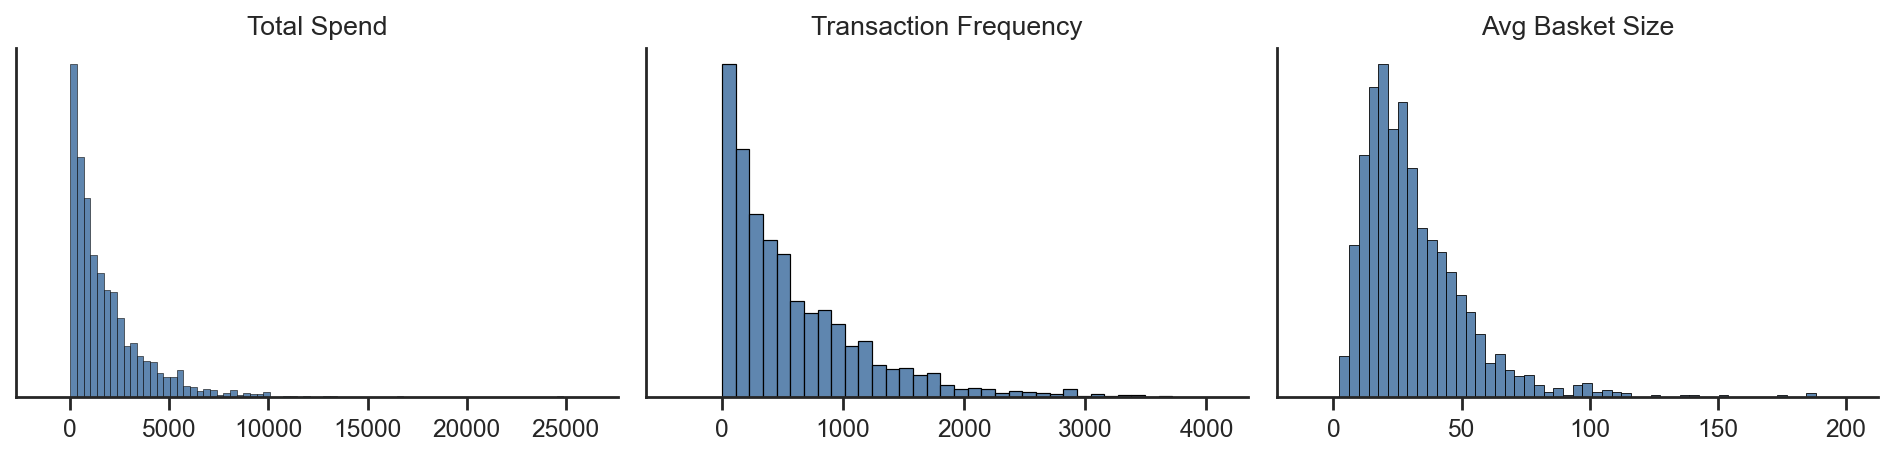

In [27]:
# Create total spend feature and split into train/valid/test
total_spend = feature_eng.total_spend(transactions)
total_spend_train = total_spend[total_spend.index.isin(transactions_train['household_id'])]
total_spend_valid = total_spend[total_spend.index.isin(transactions_valid['household_id'])]
total_spend_test  = total_spend[total_spend.index.isin(transactions_test['household_id'])]

#Create transaction frequency feature and split into train/valid/test
transaction_frequency = feature_eng.transaction_frequency(transactions)
transaction_frequency_train = transaction_frequency[transaction_frequency.index.isin(transactions_train['household_id'])]
transaction_frequency_valid = transaction_frequency[transaction_frequency.index.isin(transactions_valid['household_id'])]
transaction_frequency_test  = transaction_frequency[transaction_frequency.index.isin(transactions_test['household_id'])]

# Create average basket size feature and split into train/valid/test
average_basket_size = feature_eng.average_basket_size(transactions)
average_basket_size_train = average_basket_size[average_basket_size.index.isin(transactions_train['household_id'])]
average_basket_size_valid = average_basket_size[average_basket_size.index.isin(transactions_valid['household_id'])]
average_basket_size_test  = average_basket_size[average_basket_size.index.isin(transactions_test['household_id'])]

customer_features = pd.DataFrame({
    'Total Spend': total_spend_train,
    'Transaction Frequency': transaction_frequency_train,
    'Avg Basket Size': average_basket_size_train
})

eda.distplots(customer_features)

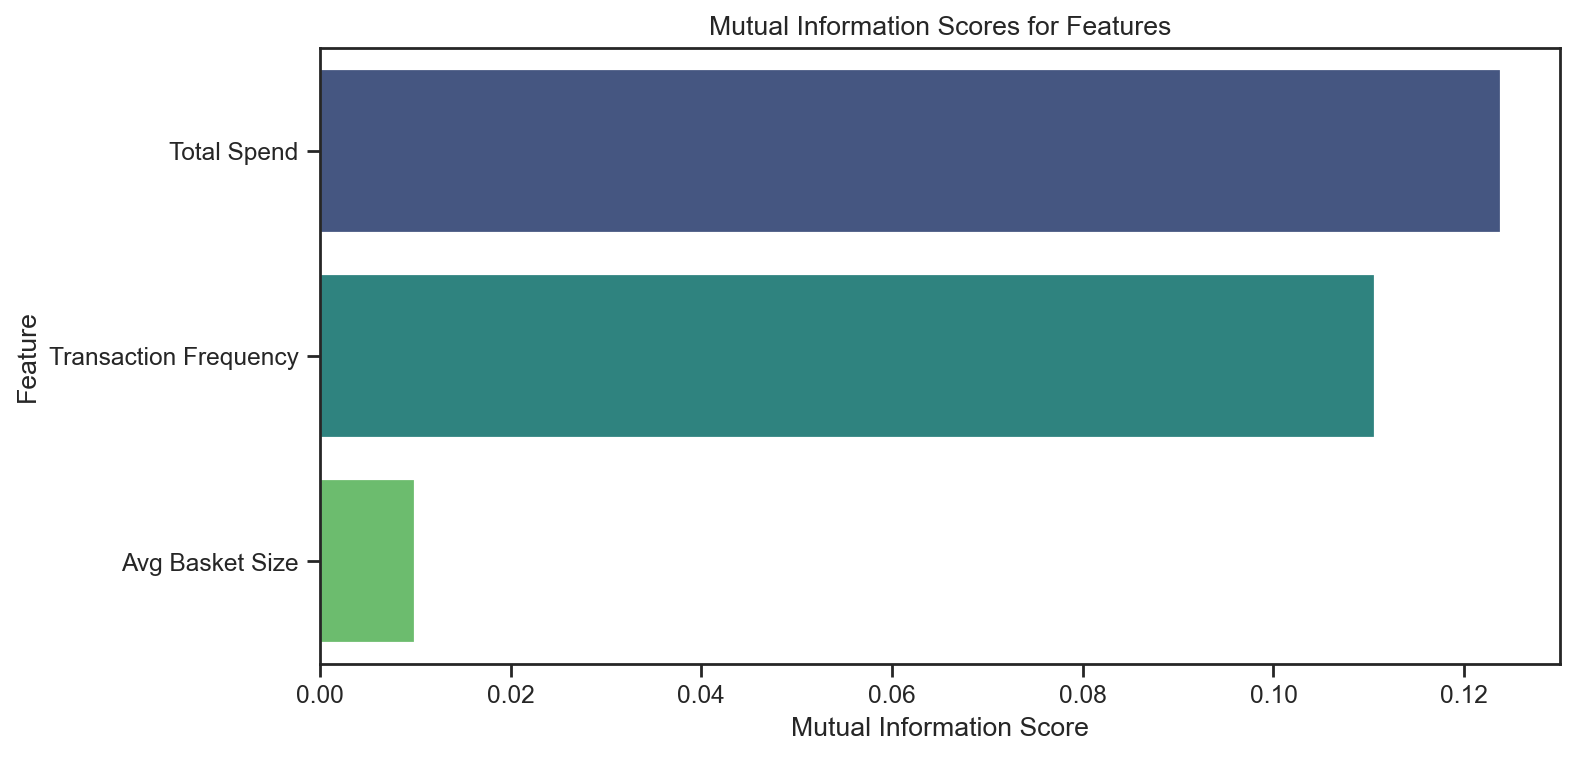

,MI
Total Spend,0.123842
Transaction Frequency,0.110611
Avg Basket Size,0.009934


In [28]:
eda.mutual_information_table(customer_features, target=churn_train, continuous= ['Total Spend', 'Transaction Frequency', 'Avg Basket Size'])

(<Figure size 960x240 with 3 Axes>,
 array([<Axes: title={'center': 'Total Spend'}>,
        <Axes: title={'center': 'Transaction Frequency'}>,
        <Axes: title={'center': 'Avg Basket Size'}>], dtype=object))

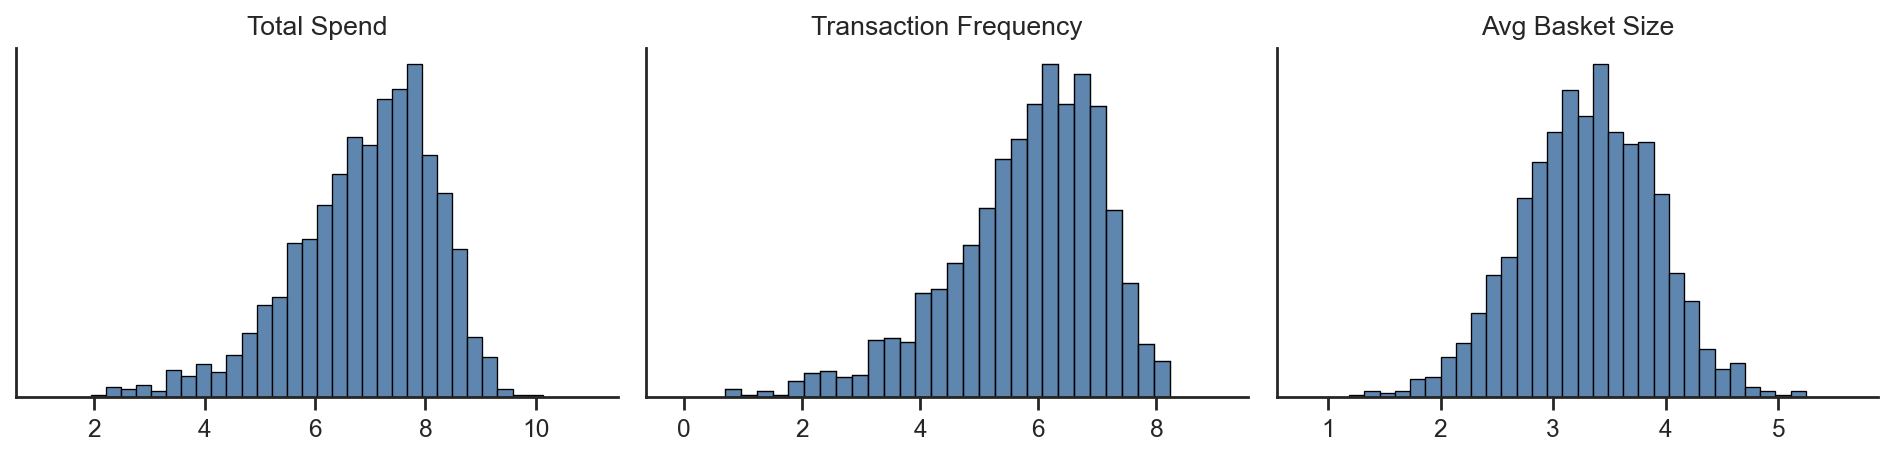

In [29]:
log_total_spend_train = np.log1p(total_spend_train)
log_total_spend_valid = np.log1p(total_spend_valid)
log_total_spend_test  = np.log1p(total_spend_test)

log_transaction_frequency_train = np.log1p(transaction_frequency_train)
log_transaction_frequency_valid = np.log1p(transaction_frequency_valid)
log_transaction_frequency_test  = np.log1p(transaction_frequency_test)

log_average_basket_size_train = np.log1p(average_basket_size_train)
log_average_basket_size_valid = np.log1p(average_basket_size_valid)
log_average_basket_size_test  = np.log1p(average_basket_size_test)

log_customer_features = pd.DataFrame({
    'Total Spend': log_total_spend_train,
    'Transaction Frequency': log_transaction_frequency_train,
    'Avg Basket Size': log_average_basket_size_train
})

eda.distplots(log_customer_features)


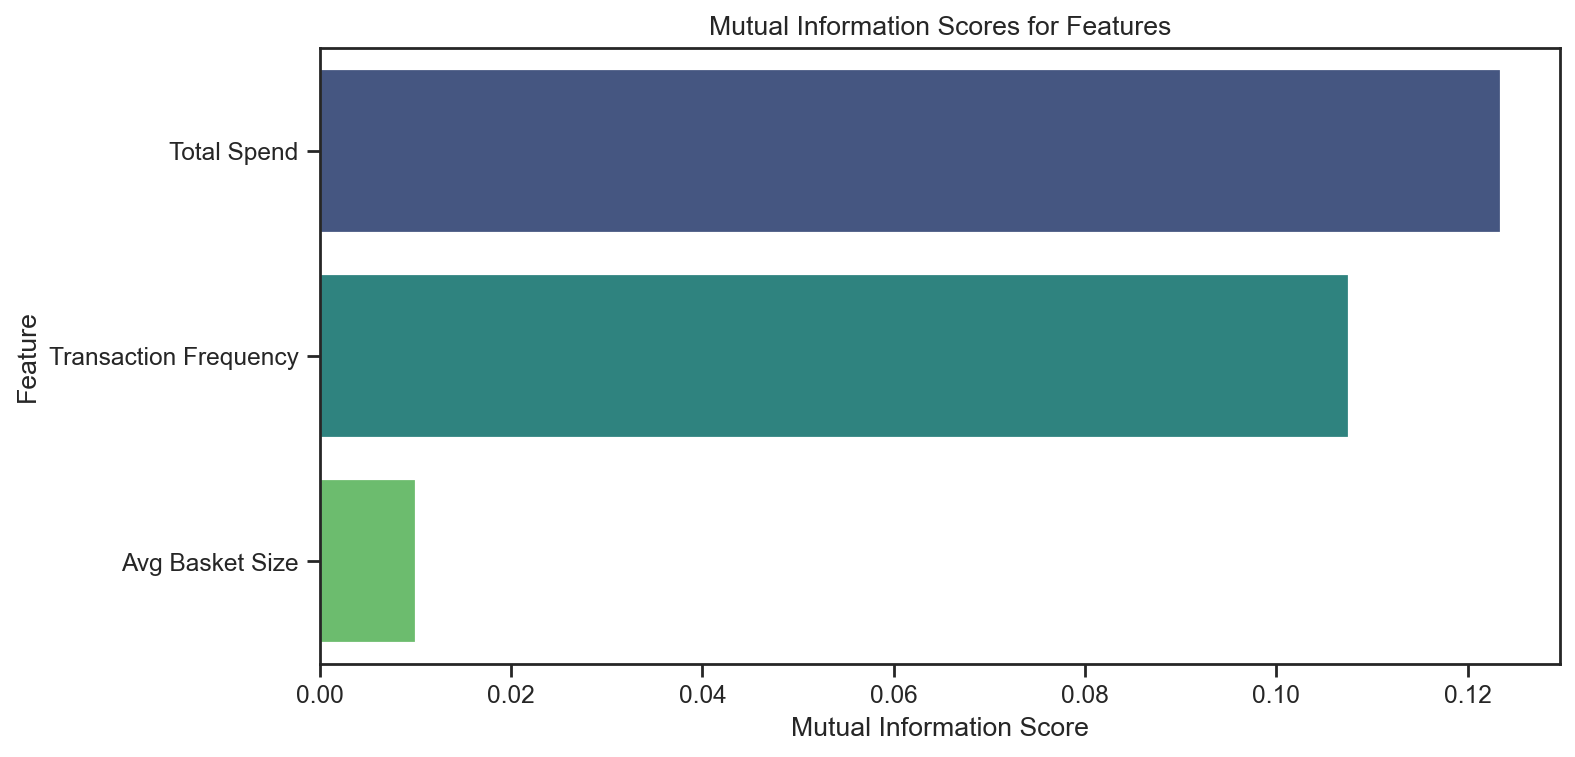

,MI
Total Spend,0.123477
Transaction Frequency,0.107595
Avg Basket Size,0.010081


In [30]:
eda.mutual_information_table(log_customer_features, target=churn_train, continuous= ['Total Spend', 'Transaction Frequency', 'Avg Basket Size'])

              spend_trend
household_id             
1               -0.408982
2                0.000000
3                0.000000
4                0.000000
6               -0.350644
...                   ...
2496            -0.678478
2497            -0.194435
2498            -0.470425
2499            -0.709088
2500            -0.215101

[2227 rows x 1 columns]
spend_trend shape: (2227, 1)
churn_aligned shape: (2227,)


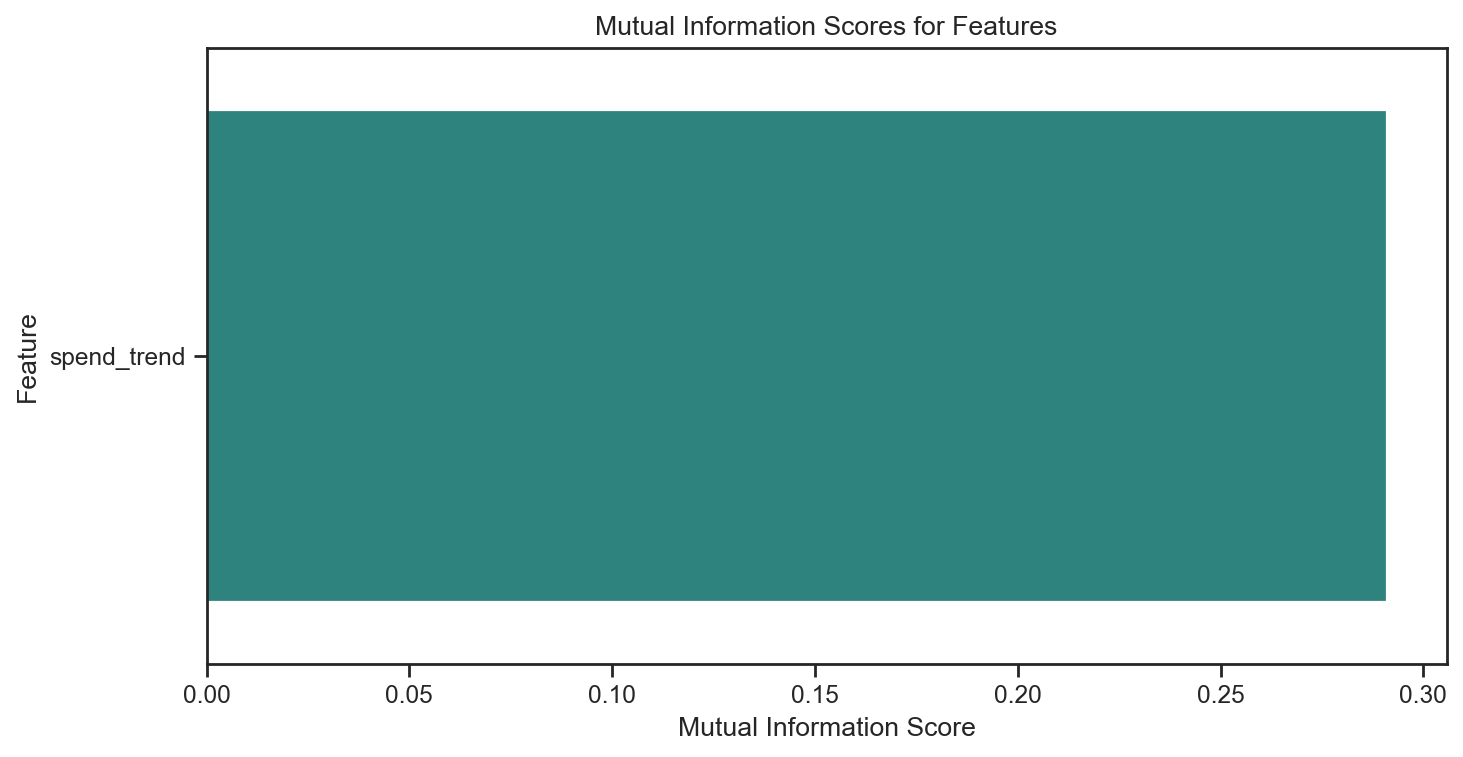

,MI
spend_trend,0.29116


In [42]:
spend_trend = feature_eng.spend_trend(eda.transactions)
print(spend_trend)

# Align churn with spend_trend (filter to matching households)
churn_aligned = churn[churn.index.isin(spend_trend.index)]
print(f"spend_trend shape: {spend_trend.shape}")
print(f"churn_aligned shape: {churn_aligned.shape}")

# Plot spend trend vs churn using mutual information
eda.mutual_information_table(spend_trend, target=churn_aligned, continuous=list(spend_trend.columns))

## Products

In [ ]:
products.head()

,product_id,manufacturer_id,department,brand,product_category,product_type,package_size
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISCELLANEOUS,National,None,None,None
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,None
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


Probably combine these categories with transactions data to get variables like brand loyalty, department diversity, category repertoire, department level spend or frequency.